예제 6.9 CNN(CIFAR-10) 파이토치

In [ ]:
# 예제 6.9 CIFAR-10(파이토치)

#셋업
import torch
import torch.nn as nn
from torch.utils.data.dataloader import DataLoader
from torch.utils.data import random_split
from torchvision.datasets import CIFAR10
from torchvision.transforms import Compose, ToTensor, Normalize
from torchvision.transforms import RandomHorizontalFlip
import numpy as np
import matplotlib.pyplot as plt

# 데이터셋 준비/전처리
transform = Compose([RandomHorizontalFlip(0.1),             # 수평 뒤집기
                     ToTensor(),                            # 텐서로 변환
                     Normalize(mean=(0.4914, 0.4822, 0.4465),    # 정규화
                               std=(0.2470, 0.2435, 0.2616))])

train_data = CIFAR10(root='./', train=True,   # 학습 데이터 다운로드/전처리
                     download=True, transform=transform)
test_data = CIFAR10(root='./', train=False,  # 테스트 데이터 다운로드/전처리
                    download=True, transform=transform)

100%|██████████| 170498071/170498071 [00:03<00:00, 46601107.34it/s]


Extracting ./cifar-10-python.tar.gz to ./
Files already downloaded and verified


In [ ]:
# 학습 데이터/검증 데이터 분할
train_data, valid_data = random_split(train_data, [0.8, 0.2])   # 분할 비율 0.2

# 데이터 로더 todtjd
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(len(train_data))    # 학습 데이터 크기 확인
print(len(valid_data))    # 검증 데이터 크기 확인
print(len(test_data))     # 테스트 데이터 크기 확인

40000
10000
10000


In [ ]:
# 모델 생성
class Cifar10Model(nn.Module):   # 모델 클래스 정의
    def __init__(self):
        super(Cifar10Model, self).__init__()
        self.feature_extractor = nn.Sequential(         # 특징 추출 신경망
            nn.Conv2d(3, 32, kernel_size=3, padding=1),   # 입력 채널 수 3
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(   # 분류 신경망
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(128 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10),
            nn.LogSoftmax(dim=1)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

# 디바이스 지정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = Cifar10Model().to(device)

In [ ]:
# 학습 함수 정의
def train_step(model, optimizer, loss_fn, train_loader, device):
    model.train()   # 학습 모드
    train_loss = 0
    train_correct = 0

    for image, label in train_loader:
        image, label = image.to(device), label.to(device)
        optimizer.zero_grad()            # 그레디언트 초기화
        outputs = model(image)           # 출력 계산
        loss = loss_fn(outputs, label)   # 손실 계산

        loss.backward()    # 역전파
        optimizer.step()   # 최적화 수행

        predict = outputs.argmax(dim=1)   # 예측
        train_correct += (predict == label).sum().item()   # 정확한 예측
        train_loss += loss.item()                          # 손실 누적값

    train_avg_loss = train_loss / len(train_loader)    # 학습 손실
    train_accuracy = train_correct / len(train_data)   # 학습 정확도
    return train_avg_loss, train_accuracy

# 검증 함수 정의
def validation_step(model, loss_fn, valid_loader, device):
    model.eval()   # 평가 모드
    valid_loss = 0
    valid_correct = 0

    with torch.no_grad():   # 자동 미분하지 않음
        for image, label in valid_loader:
            image, label = image.to(device), label.to(device)
            outputs = model(image)                             # 출력 계산
            loss = loss_fn(outputs, label)                     # 손실 계산

            predict = outputs.argmax(dim=1)                    # 예측
            valid_correct += (predict == label).sum().item()   # 정확한 예측
            valid_loss += loss.item()                          # 누적 손실값

    valid_avg_loss = valid_loss / len(valid_loader)    # 검증 손실
    valid_accuracy = valid_correct / len(valid_data)   # 검증 정확도
    return valid_avg_loss, valid_accuracy

In [ ]:
# 하이퍼파라미터 설정
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# 모델 학습
epochs = 50          # 반복 횟수

patience = 3         # 조기 종료 조건
best_loss = np.inf   # 초기 손실값
counter = 0

train_losses = []   # 시각화 리스트
train_accuracies = []
valid_losses = []
valid_accuracies = []

for epoch in range(epochs):
    train_avg_loss, train_accuracy = train_step(model, optimizer, loss_fn,
                                                train_loader, device)
    train_losses.append(train_avg_loss)
    train_accuracies.append(train_accuracy)

    valid_avg_loss, valid_accuracy = validation_step(model, loss_fn,
                                                     valid_loader, device)
    valid_losses.append(valid_avg_loss)
    valid_accuracies.append(valid_accuracy)

    if valid_avg_loss < best_loss:   # 조기 종료 검사
        best_loss = valid_avg_loss
        counter = 0
    else:
        counter += 1

        if counter == patience:
            break

    print(f"Epoch {epoch+1}/{epochs} \t loss: {train_avg_loss:.4f}"
          f"\t accuracy: {train_accuracy:.4f} \t val_loss: {valid_avg_loss:.4f}"
          f"\t val_accuracy: {valid_accuracy:.4f}")

Epoch 1/50 	 loss: 1.6336	 accuracy: 0.3935 	 val_loss: 1.2310	 val_accuracy: 0.5596
Epoch 2/50 	 loss: 1.2432	 accuracy: 0.5544 	 val_loss: 1.0349	 val_accuracy: 0.6355
Epoch 3/50 	 loss: 1.0820	 accuracy: 0.6167 	 val_loss: 0.9119	 val_accuracy: 0.6826
Epoch 4/50 	 loss: 0.9854	 accuracy: 0.6545 	 val_loss: 0.8567	 val_accuracy: 0.6994
Epoch 5/50 	 loss: 0.9169	 accuracy: 0.6787 	 val_loss: 0.8337	 val_accuracy: 0.7077
Epoch 6/50 	 loss: 0.8685	 accuracy: 0.6998 	 val_loss: 0.7733	 val_accuracy: 0.7355
Epoch 7/50 	 loss: 0.8235	 accuracy: 0.7134 	 val_loss: 0.7529	 val_accuracy: 0.7363
Epoch 8/50 	 loss: 0.7974	 accuracy: 0.7247 	 val_loss: 0.7800	 val_accuracy: 0.7282
Epoch 9/50 	 loss: 0.7640	 accuracy: 0.7366 	 val_loss: 0.7295	 val_accuracy: 0.7484
Epoch 10/50 	 loss: 0.7505	 accuracy: 0.7423 	 val_loss: 0.7208	 val_accuracy: 0.7582
Epoch 11/50 	 loss: 0.7279	 accuracy: 0.7497 	 val_loss: 0.6936	 val_accuracy: 0.7593
Epoch 12/50 	 loss: 0.7122	 accuracy: 0.7557 	 val_loss: 0.6874

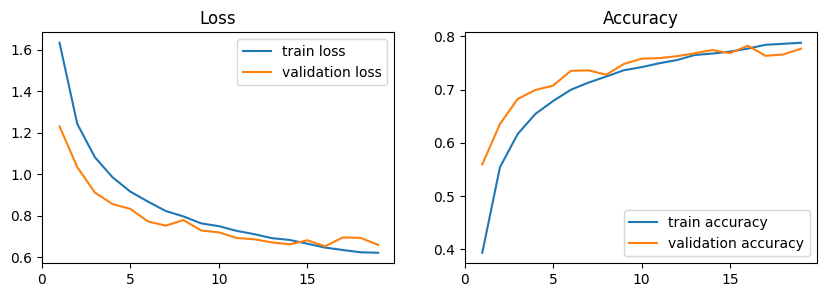

In [ ]:
# 학습 결과 시각화
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

ax = axs[0]
ax.plot(range(1, len(train_losses) + 1), train_losses,
        label='train loss')
ax.plot(range(1, len(valid_losses) + 1), valid_losses,
        label='validation loss')
ax.set_title('Loss')
ax.set_xticks(range(0, epoch+2, 5))
ax.legend(loc='best')

ax = axs[1]
ax.plot(range(1, len(train_accuracies) + 1), train_accuracies,
        label='train accuracy')
ax.plot(range(1, len(valid_accuracies) + 1), valid_accuracies,
        label='validation accuracy')
ax.set_title('Accuracy')
ax.set_xticks(range(0, epoch+2, 5))
ax.legend(loc='best')

plt.show()

In [ ]:
# 모델 평가
model.eval()  # 평가 모드
correct = 0

with torch.no_grad():   # 평가할 때는 그레디언트 계산하지 않음
    for image, label in test_loader:
        image, label = image.to(device), label.to(device)
        outputs = model(image)                       # 출력 계산
        predict = outputs.argmax(dim=1)              # 예측
        correct += (predict == label).sum().item()   # 정확한 예측

    accuracy = correct / len(test_data)              # 정확도 계산

    print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7780
